# KNN Project
## Group Members:
- **Benjamin Nelson**: Wrote the bulk of the code for our KNN algorithm
- **Cole Clodgo**: Wrote the markdown explanations
- **Kaiden McCready**: Handled getting the datasets in and doing preprocessing of the data
- **Kosei Yamaguchi**: Ran experiments and tested the code
## Project Explanation
K Nearest Neighbors is a machine learning algorithm that classifies data points based on the labels of nearby points. Our algorithm takes data points, an unlabeled point, and a value for k as inputs. It then computes the distance between the unlabeled point and every labeled data point. We then look at the k points that are closest to the unlabeled point, and whichever label has a simple majority is assigned to the unlabeled point.
## Data
We run our KNN algorithm on two different datasets. These datasets allow us to test our algorithm using real data with different dimensions. 
### Fisher Iris Data
The first dataset is the Fisher Iris Data set. This dataset contains 150 samples of iris flowers. These samples are categorized into 4 species and have 4 numeric attributes. We use these attributes to categorize an unlabeled sample into one of the four species by using the numeric values for the attributes to find the "distance" between the samples. We then categorize the new sample by using the other samples' species as their labels.

In [2]:
# ***
# Prerequisites:
# pip install ucimlrepo
# ***

from ucimlrepo import fetch_ucirepo 
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
  
# fetch dataset 
iris = fetch_ucirepo(id=53) 
  
# data (as pandas dataframes) 
x = iris.data.features 
y = iris.data.targets 

# from 'cleanup.ipynb'
iris_training_set = pd.read_csv("Iris_training_data.csv").to_numpy()

def adapt_for_bens_LoL(numpy_array):
    n_parameters = len(numpy_array[0]) - 1
    # magic box that turns [[5], ...] into [[[4], [1]], ...]. probably slow when working with big datasets.
    return [[row[:n_parameters].tolist(), row[n_parameters]] for row in numpy_array] 

iris_training_set = adapt_for_bens_LoL(iris_training_set)
print(iris_training_set)


[[[0.5833333333333334, 0.2916666666666667, 0.7288135593220338, 0.75], 'Iris-virginica'], [[0.5555555555555555, 0.3333333333333332, 0.6949152542372881, 0.5833333333333334], 'Iris-virginica'], [[0.1944444444444444, 0.4166666666666666, 0.1016949152542373, 0.0416666666666666], 'Iris-setosa'], [[0.5833333333333334, 0.5, 0.7288135593220338, 0.9166666666666666], 'Iris-virginica'], [[0.4166666666666666, 0.3333333333333332, 0.6949152542372881, 0.9583333333333331], 'Iris-virginica'], [[0.2777777777777777, 0.7083333333333333, 0.0847457627118644, 0.0416666666666666], 'Iris-setosa'], [[0.5833333333333334, 0.3333333333333332, 0.7796610169491525, 0.8333333333333334], 'Iris-virginica'], [[0.1944444444444444, 0.6666666666666666, 0.0677966101694915, 0.0416666666666666], 'Iris-setosa'], [[0.4444444444444445, 0.4166666666666666, 0.6949152542372881, 0.7083333333333334], 'Iris-virginica'], [[1.0, 0.7499999999999998, 0.9152542372881356, 0.7916666666666666], 'Iris-virginica'], [[0.25, 0.2916666666666667, 0.49

In [6]:
import math

"""
Inputs: data = [[[values],[lables]],[[values1],[lables1]],...], pointToFind = [value1, value2, ...], k = int
Outputs: retLabel = label of the pointToFind based on the k nearest neighbors in data
----------------------------------------
First it run through all the points and only holds on to the k closest points to the pointToFind. 
If a point is closer than another it replaces it in Closest. 
Then it calculates the weight of each point based on how close it is to the pointToFind.
Finally it sums up the weights for each label and returns the label with the highest weight.
"""


def KNN(data, pointToFind, k, Unweighted = False):
  #find Closests
  #closest[0] = dist, [1] = value, [2] = labels, [3] = weight
  
  Closest = {"Dist": [], "Value": [], "Labels": [], "Weight": []}
  for Point in data:
    dist = 0
    for variableId in range(len(Point[0])):
      dist += ((pointToFind[variableId]-Point[0][variableId])**2)
    dist = math.sqrt(dist)
    
    #add to Closest
    if len(Closest["Dist"]) >= k:
      compareItem = max(Closest["Dist"])
      if compareItem > dist:
        #get indexs and choose the first one
        index = Closest["Dist"].index(compareItem)
        Closest["Dist"][index] = dist
        Closest["Value"][index] = Point[0]
        Closest["Labels"][index] = Point[1]
        Closest["Weight"][index] = [0]
    else:
      Closest["Dist"].append(dist)
      Closest["Value"].append(Point[0])
      Closest["Labels"].append(Point[1])
      Closest["Weight"].append([0])


  #Comparaisons[0] = labels, Comparaisons[1] = total weight
  Comparaisons = {"Labels": [], "Weights": []}
  for itemIndex in range(len(Closest["Dist"])):

    #weighting by the inverse of the distance if weighted, otherwise just 1.
    value = 1
    if not Unweighted:
      value = 1 - Closest["Dist"][itemIndex]

    Closest["Weight"][itemIndex] = value
  
    if Closest["Labels"][itemIndex] not in Comparaisons["Labels"]:
      Comparaisons["Labels"].append(Closest["Labels"][itemIndex]) 
      Comparaisons["Weights"].append(Closest["Weight"][itemIndex])
       
    else:
      CompIndex = Comparaisons["Labels"].index(Closest["Labels"][itemIndex])
      Comparaisons["Weights"][CompIndex] += Closest["Weight"][itemIndex]
    
  
  
  retLabel = Comparaisons["Labels"][Comparaisons["Weights"].index(max(Comparaisons["Weights"]))] #from labels, the one with the highest weighted score

  return retLabel

In [7]:
#Test to make sure KNN works on a basic input.
data = [[[8.0,27.0,0.0,9.4],["cool"]],[[89.0,27.0,1.0,69.4],["rad"]],[[87.0,27.0,0.0,97.4],["cool"]],[[90.0,90.0,3.0,25.4],["uncool"]],[[95.0,23.0,3.0,80.4], ["rad"]]]
point = [105.0,90.0,2.0,85.4]

KNN(data, point, 3)

['uncool']

In [8]:
# [-1.3807270877331406,0.3367202847780191,-1.3934698549528162,-1.3085928194379575] -> Iris-setosa as a test case.
iris_test_point = [-1.3807270877331406,0.3367202847780191,-1.3934698549528162,-1.3085928194379575]
KNN(data=iris_training_set, pointToFind=iris_test_point, k=3)


'Iris-setosa'

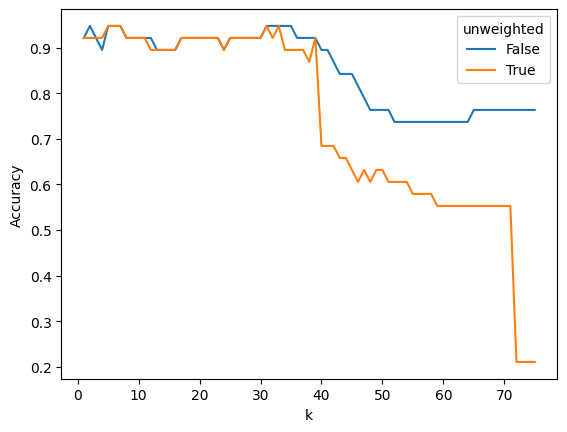

In [9]:
iris_evaluating_set = pd.read_csv("Iris_testing_data.csv")

# format test points to ben's LoL
eval_points = iris_evaluating_set.drop(columns="Species").values.tolist()

# evaluate k options + accuracies
evaluations = pd.DataFrame(columns=["weighted", "k", "accuracy"])


for evaltype in [True, False]:
    # check k 1 - 75
    for k in range(1, 76):    

        # run the model on each point in the test set (eval_points)
        iris_evaluating_set["Predicted"] = [KNN(iris_training_set, point, k, Unweighted=evaltype) for point in eval_points]
        # check to see if each prediction was correct
        iris_evaluating_set["Correct?"] = iris_evaluating_set["Species"] == iris_evaluating_set["Predicted"]
        # get the % of accurate predictions
        accuracy = iris_evaluating_set["Correct?"].mean()
        evaluations = pd.concat([evaluations, pd.DataFrame([{'unweighted': evaltype, 'k': k, 'accuracy': accuracy}])], ignore_index=True)
        # print(f"k = {k}; accuracy = {accuracy.round(5)}")


_ = sns.lineplot(data=evaluations, x="k", y="accuracy", hue="unweighted")
plt.xlabel('k')
plt.ylabel('Accuracy')
plt.show()

## Experiment 
In this section, we investigate how different values of K affect the accuracy of our K-nearest neighbors (KNN) classifier. We also conduct an additional experiment to examine how the amount of training data affects KNN performance.

### experiment 1: Effect of K on accuracy
We hypothesized that changing K would affect classification accuracy because K determines how many neighboring points are considered when making a prediction. Smaller values of K use fewer nearby points and may be more sensitive to individual observations, while larger values of K consider more points when determining the predicted class.

To investigate the effect of K, we tested values of K from 1 to 75. We kept the training and testing datasets fixed and changed only the value of K. For each value of K, we calculated the percentage of test points that were correctly classified.

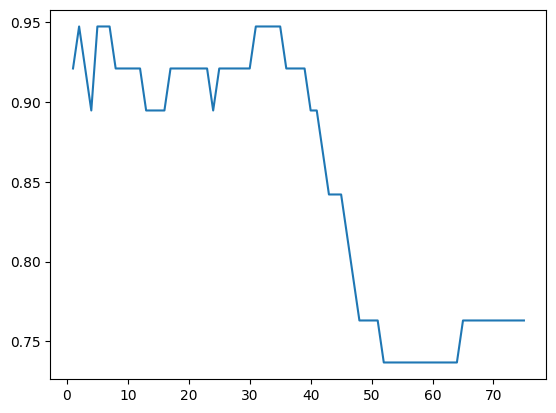

In [41]:
iris_evaluating_set = pd.read_csv("Iris_testing_data.csv")

# format test points to ben's LoL
eval_points = iris_evaluating_set.drop(columns="Species").values.tolist()

# evaluate k options + accuracies
evaluations = pd.DataFrame(columns=["k", "accuracy"])

# check k 1 - 75
for k in range(1, 76):    

    # run the model on each point in the test set (eval_points)
    iris_evaluating_set["Predicted"] = [KNN(iris_training_set, point, k,Unweighted=False) for point in eval_points]
    # check to see if each prediction was correct
    iris_evaluating_set["Correct?"] = iris_evaluating_set["Species"] == iris_evaluating_set["Predicted"]
    # get the % of accurate predictions
    accuracy = iris_evaluating_set["Correct?"].mean()
    evaluations = pd.concat([evaluations, pd.DataFrame([{'k': k, 'accuracy': accuracy}])], ignore_index=True)
    # print(f"k = {k}; accuracy = {accuracy.round(5)}")

_ = plt.plot(evaluations["k"], evaluations["accuracy"]) # this apparently stops the class from printing randomly when displaying the plot


### experiment 2: Effect of Training Data Size on Accuracy

Hypothesis: We hypothesized that the amount of training data would affect KNN accuracy and its sensitivity to the choice of K. We expected that smaller training datasets would be more sensitive to larger values of K because fewer training examples are available, causing larger K values to include more distant observations. We also expected that increasing the amount of training data would generally provide more nearby examples and make KNN performance more stable across different values of K

We investigated how the amount of training data affects KNN accuracy. We tested training-data ratios of 30%, 40%, 50%, 60%, 70%, 80%, and 90%. For each training ratio, we tested K values from 1 to 25.

For this experiment, each training ratio was randomly split into a training set and a testing set. The graph below shows accuracy as the amount of training data increases for several representative values of K.


[[5.1, 3.5, 1.4, 0.2], 'Iris-setosa']
Training ratio = 0.3 K = 1 Correct = 42 Total = 45 Accuracy = 93.33 %
Training ratio = 0.3 K = 2 Correct = 42 Total = 45 Accuracy = 93.33 %
Training ratio = 0.3 K = 3 Correct = 45 Total = 45 Accuracy = 100.0 %
Training ratio = 0.3 K = 4 Correct = 45 Total = 45 Accuracy = 100.0 %
Training ratio = 0.3 K = 5 Correct = 45 Total = 45 Accuracy = 100.0 %
Training ratio = 0.3 K = 6 Correct = 45 Total = 45 Accuracy = 100.0 %
Training ratio = 0.3 K = 7 Correct = 43 Total = 45 Accuracy = 95.56 %
Training ratio = 0.3 K = 8 Correct = 43 Total = 45 Accuracy = 95.56 %
Training ratio = 0.3 K = 9 Correct = 41 Total = 45 Accuracy = 91.11 %
Training ratio = 0.3 K = 10 Correct = 41 Total = 45 Accuracy = 91.11 %
Training ratio = 0.3 K = 11 Correct = 41 Total = 45 Accuracy = 91.11 %
Training ratio = 0.3 K = 12 Correct = 40 Total = 45 Accuracy = 88.89 %
Training ratio = 0.3 K = 13 Correct = 39 Total = 45 Accuracy = 86.67 %
Training ratio = 0.3 K = 14 Correct = 39 Total =

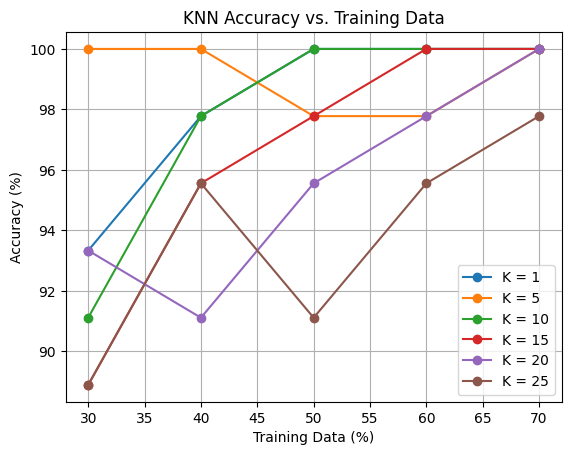

In [42]:
file_path = "/Users/koseiyamaguchi/CS240/ml-240-project1/iris_example_project/Iris.csv"
features = np.genfromtxt(file_path, delimiter=',', usecols=(1,2,3,4), skip_header=1).tolist()
species = np.genfromtxt(file_path, delimiter=',', usecols=5, dtype = str, skip_header=1).tolist()
data= []

for i in range(len(features)):
    data.append([features[i], species[i]])

print(data[0])


def test_accuracy(train_data, test_data, k):
    correct = 0

    for point in test_data:
        prediction = KNN(train_data, point[0], k,Unweighted=False)

        if prediction == point[1]:
            correct += 1

    accuracy = correct / len(test_data)

    return correct, accuracy


np.random.seed(42)
train_ratios = [0.3, 0.4 ,0.5, 0.6, 0.7]
indices = np.random.permutation(len(data))

test_size = int(len(data) * 0.3)   # 45 observations
test_indices = indices[:test_size]
training_indices = indices[test_size:]   # 105 observations

test_data = [data[i] for i in test_indices]

results = {}

for ratio in train_ratios:

    train_size = int(len(data) * ratio)
    train_indices = training_indices[:train_size]

    train_data = [data[i] for i in train_indices]

    results[ratio] = {}

    for k in range(1, 26):

        correct, accuracy = test_accuracy(train_data, test_data, k)

        results[ratio][k] = accuracy

        print(
            "Training ratio =", ratio,
            "K =", k,
            "Correct =", correct,
            "Total =", len(test_data),
            "Accuracy =", round(accuracy * 100, 2), "%"
        )
##training data ratio => x-axis, accuracy => y-axis, line=>varying K value
k_values = [1, 5, 10, 15, 20, 25]

for k in k_values:

    accuracies = []
    for ratio in train_ratios:
        accuracies.append(results[ratio][k] * 100)

    plt.plot(
        [ratio * 100 for ratio in train_ratios],
        accuracies,
        marker='o',
        label="K = " + str(k)
    )

plt.xlabel("Training Data (%)")
plt.ylabel("Accuracy (%)")
plt.title("KNN Accuracy vs. Training Data")
plt.legend()
plt.grid()

plt.show()

#### Result: 
As the amount of training data increased from 30% to 70%, accuracy generally improved or remained high for most values of K. For example, K=10 increased from about 91.7% accuracy at 30% training data to about 98.3% at 50% training data and remained at that level as more training data was added. K=15 showed a similar pattern, increasing from 90% to 100%. However, the relationship was not perfectly consistent for every K. K=5 and K=25 showed some decreases before recovering at larger training sizes. Overall, the results suggest that providing KNN with more training data can improve or maintain classification accuracy, although the effect depends on the value of K.

Limitations: First, the test set contained 45 observations, so the measured accuracy was still somewhat coarse. One incorrect prediction changes the accuracy by about 2.22 percentage points. Second, we used only one random data split, so the results may depend on which observations were selected for the test set. Repeating the experiment with multiple random splits and averaging the results could provide a more reliable measure of KNN performance.



### Experiment 3: Effect of K at Different Training-Data Ratios

In Experiment 3, we use the results from Experiment 2 to examine how K affects accuracy at different training-data ratios. Instead of plotting training-data ratio against accuracy, we plot K against accuracy and use a separate line for each training-data ratio. This allows us to compare the sensitivity to K across different amounts of training data.

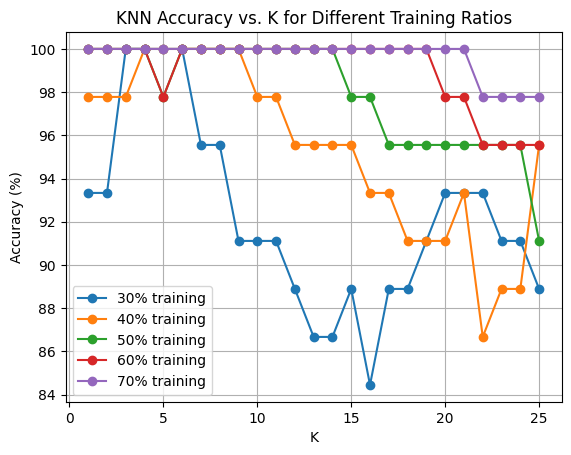

In [40]:
for ratio in train_ratios:

    accuracies = []

    for k in range(1, 26):
        accuracies.append(results[ratio][k] * 100)

    plt.plot(
        range(1, 26),
        accuracies,
        marker='o',
        label=str(int(ratio * 100)) + "% training"
    )

plt.xlabel("K")
plt.ylabel("Accuracy (%)")
plt.title("KNN Accuracy vs. K for Different Training Ratios")
plt.legend()
plt.grid()
plt.show()

#### Result:
The value of K had a noticeable effect on accuracy across the different training-data ratios. At lower training-data ratios, accuracy fluctuated more as K changed. For example, with 30% training data, accuracy varied considerably across K values, while the 70% training-data curve remained at relatively high accuracy for a larger range of K values. However, the effect of increasing K was not consistent across all training-data ratios, suggesting that the best-performing K can depend on the amount of training data.
